# EOS tutorial

This tutorial will cover the H-He and metals (Z) EOS submodule, how they are initialized, and how they are used in `ORCHARD`.

**Units cheat sheet for this tutorial:**
- Pressures and temperatures are stored as base-10 logs of cgs units (`logp` in dyn/cm², `logt` in K).
- Densities are `logrho` in log$_{10}$ g/cm³.
- Entropy comes in two flavors. The "raw" function variants (`get_s_pt_val`, `get_s_h`, `get_s_he`, etc.) return entropy in **erg/g/K**. The pre-tabulated variants (`get_s_pt`, etc.) and all `S` arguments to inversion functions like `get_logt_sp_inv(s, ...)` use **k$_B$/baryon** (the unit used everywhere else in `ORCHARD` and in parameter files).
- Convert with `eos_class.erg_to_kbbar = 1.20272 × 10⁻⁸` (multiply erg/g/K by this to get k$_B$/baryon; divide to go back).

If you call a `_val` getter and the entropy magnitudes look ~10⁸ too big, you forgot the `erg_to_kbbar` factor.

## H and He EOSes

In this short section, we will show the H and He EOSes of Chabrier et al. (2019), since the H EOS of Chabrier et al. (2021) should only be used for mixtures (next section). The units of the H-He EOSes are in log 10 Kelvin for temperature, and log 10 cgs units for the rest of the quantities. For mixtures, and for later convenience, the output of the entropy will be in units of kB/baryon. 

In [1]:
import numpy as np
from eos import eos_class

cms_eos = eos_class.hhe_eos(hhe_eos='cms') # CMS19 EOS (options are cms, or cd; Chabrier et al. (2019, 2021))

# Grid from 1 bar to 100 Mbar in dyn/cm^2
logp_grid = np.linspace(6, 15, 100)  # log10(p) in dyn/cm^2 [1 bar to 1000 Mbar]
logt_const = np.full_like(logp_grid, 4.0)  # log10(T) in K [10,000 K for example here]
logrho_H = cms_eos.get_logrho_h(logp_grid, logt_const)  # log10(rho) in g/cm^3
logrho_He = cms_eos.get_logrho_he(logp_grid, logt_const)  # log10(rho) in g/cm^3

s_H = cms_eos.get_s_h(logp_grid, logt_const)  # Specific entropy for H
s_He = cms_eos.get_s_he(logp_grid, logt_const)  # Specific entropy for He

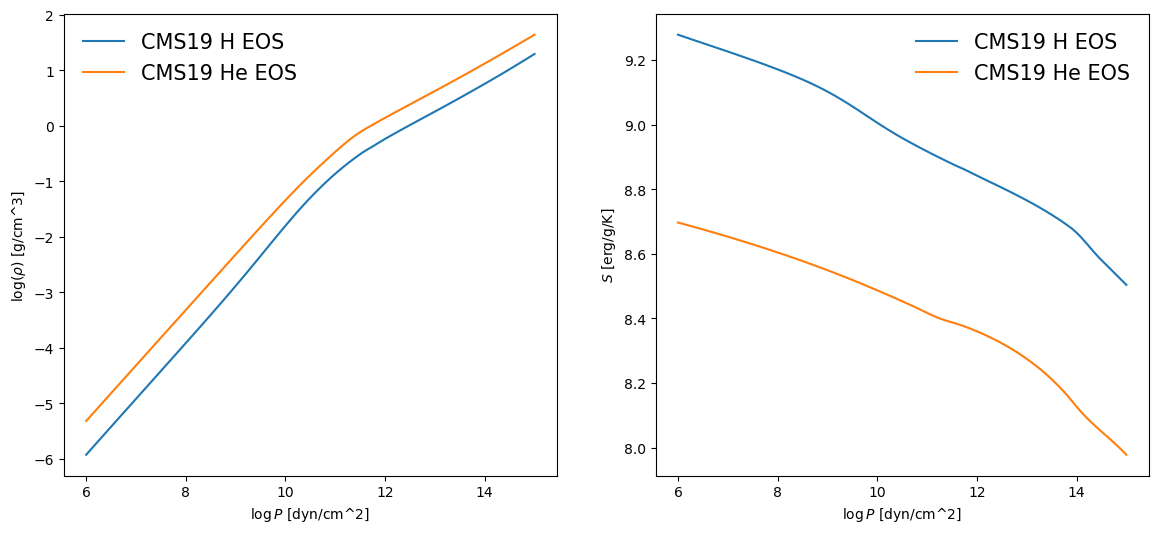

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

ax1.plot(logp_grid, logrho_H, label='CMS19 H EOS')
ax1.plot(logp_grid, logrho_He, label='CMS19 He EOS')
ax1.set_xlabel(r'$\log{P}$ [dyn/cm^2]')
ax1.set_ylabel(r'$\log(\rho)$ [g/cm^3]')
ax1.legend(frameon=False, prop={'size': 15})

ax2.plot(logp_grid, s_H, label='CMS19 H EOS')
ax2.plot(logp_grid, s_He, label='CMS19 He EOS')
ax2.set_xlabel(r'$\log{P}$ [dyn/cm^2]')
ax2.set_ylabel(r'$S$ [erg/g/K]')
ax2.legend(frameon=False, prop={'size': 15})

plt.show()

# H-He mixtures

The `eos_class.mixtures()` class is the main EOS callable in `ORCHARD`. Below, I show how to initialize it and call its various thermodynamic functions. Upon initialization, you must specify the H-He EOS to use (either `cms`, `cd`, or `scvh`), whether your $Y$ input is actually $Y/(X + Y)$ or the absolute $Y$ with `y_prime = True` (or `False`), and whether to use the non-ideal corrections published by Howard \& Guillot (2023) on the Chabrier et al. (2019) H-He EOS. 

The `mixtures()` class houses voluem-addition law $\rho(P, T)$, $S(P, T)$, and $U(P, T)$ quantities in log 10 cgs units. These functions are called, for example, `get_logrho_pt_val(_lgp, _lgt, ...)`. Precomputed tables of mixtures also exist across the relevant parameter space for planets, and these are accessible through functions without the `_val` name suffix. 

**IMPORTANT**: All getter functions tell you which thermodynamic variable comes first in the argument order. For example, `get_logrho_pt(logp, logt)` takes in `(logp, logt)` in that order.

Below are example usage ,with isotherms for simplicity, of a few Y values. 

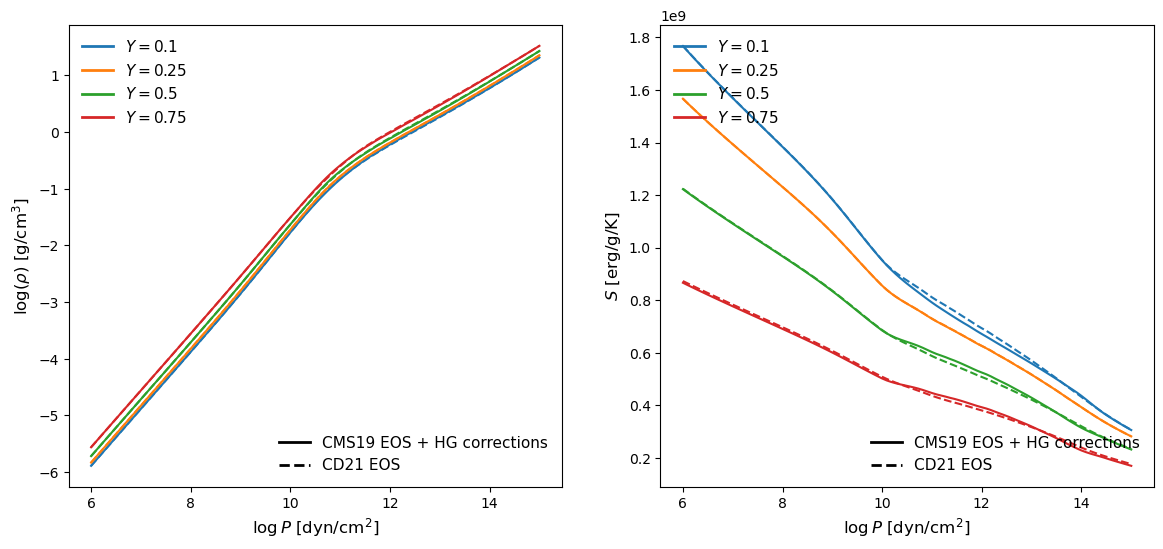

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from eos import eos_class

cms_hg_eos = eos_class.mixtures(hhe_eos='cms', hg=True ,y_prime=True) # CMS19 EOS with Howard & Guillot (2023) entropy, density, and internal energy non-ideal corrections
cd_eos = eos_class.mixtures(hhe_eos='cd', y_prime=True) # CD21 EOS (already incorporates non-ideal corrections via Militzer & Hubbard (2013) and Chabrier et al. (2019))

# Grid from 1 bar to 1000 Mbar in dyn/cm^2
logp_grid = np.linspace(6, 15, 100)  # log10(p) in dyn/cm^2 [1 bar to 1000 Mbar]
logt_const = np.full_like(logp_grid, 4.0)  # log10(T) in K [10,000 K for example here]
y_values = [0.1, 0.25, 0.5, 0.75]  # Mass fractions (Y) of helium
z_values = np.zeros(len(logp_grid)) # Zero metallicity for this example

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

colors = {0.1: 'C0', 0.25: 'C1', 0.5: 'C2', 0.75: 'C3'}

for i, y in enumerate(y_values):
    y_ = np.full_like(logp_grid, y)
    logrho_cms_hg = cms_hg_eos.get_logrho_pt(logp_grid, logt_const, y_, z_values)
    logrho_cd = cd_eos.get_logrho_pt(logp_grid, logt_const, y_, z_values)

    ax1.plot(logp_grid, logrho_cms_hg, color=f'C{i}', ls='-')
    ax1.plot(logp_grid, logrho_cd,     color=f'C{i}', ls='--')

    logs_cms_hg = cms_hg_eos.get_s_pt(logp_grid, logt_const, y_, z_values)
    logs_cd = cd_eos.get_s_pt(logp_grid, logt_const, y_, z_values)

    ax2.plot(logp_grid, logs_cms_hg, color=f'C{i}', ls='-')
    ax2.plot(logp_grid, logs_cd,     color=f'C{i}', ls='--')

# Legend 1: colors → Y values
color_handles = [
    Line2D([0], [0], color='C0', ls='-', lw=2, label=r'$Y = 0.1$'),
    Line2D([0], [0], color='C1', ls='-', lw=2, label=r'$Y = 0.25$'),
    Line2D([0], [0], color='C2', ls='-', lw=2, label=r'$Y = 0.5$'),
    Line2D([0], [0], color='C3', ls='-', lw=2, label=r'$Y = 0.75$'),
]

# Legend 2: linestyles → EOS models
style_handles = [
    Line2D([0], [0], color='k', ls='-', lw=2, label='CMS19 EOS + HG corrections'),
    Line2D([0], [0], color='k', ls='--', lw=2, label='CD21 EOS'),
]

for ax in (ax1, ax2):
    leg1 = ax.legend(handles=color_handles, frameon=False, loc='upper left', prop={'size': 11})
    ax.add_artist(leg1)  # keep first legend when adding second
    ax.legend(handles=style_handles, frameon=False, loc='lower right', prop={'size': 11})

ax1.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax1.set_ylabel(r'$\log(\rho)$ [g/cm$^3$]', fontsize=12)

ax2.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax2.set_ylabel(r'$S$ [erg/g/K]', fontsize=12)

plt.show()

# H-He adiabats and other inversions

`ORCHARD` relies on $S(\log{P}, \log{T})$ -> $\log{T}(S, \log{P})$ inversions. This is provided by a direct numerical inversion function called `get_logt_sp_inv()`, but precomputed tables of this inversion also exist and can be called via `get_logt_sp_tab()`.

 By calculating the temperature at a constant entropy, we obtain an isentropic, or adiabatic, temperature profile. Note that the output units of `get_s_pt()` are in cgs units, but the input entropy values of, say, `get_logt_sp_inv(s, logp, Y, Z)` are in kb/baryon.

 Recall from above that the `get_logt_sp_inv()` function takes in `(S, logp)` in that order, and logp is in log 10 cgs units. 

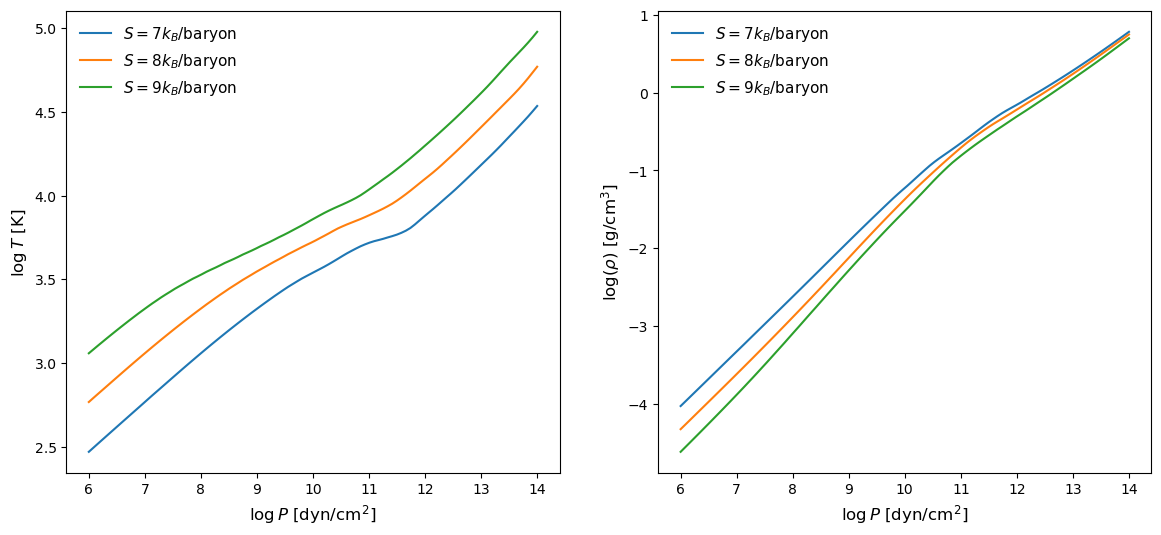

In [4]:
isentropic_s_values = [7, 8, 9] # constant entropy values in kB/baryon
logp_grid = np.linspace(6, 14, 100)  # log10(p) in dyn/cm^2 [1 bar to 100 Mbar]
y_value = np.full_like(logp_grid, 0.25)  # Fixed helium mass fraction (Y)
z_value = np.zeros_like(logp_grid)  # Zero metallicity for now

cd_eos = eos_class.mixtures(hhe_eos='cd', y_prime=True)

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

for s in isentropic_s_values:
    s_const = np.full_like(logp_grid, s)  # Constant entropy in kB/baryon
    logt_isentrope, converged = cd_eos.get_logt_sp_inv(s_const, logp_grid, y_value, z_value)
    logrho_isentrope = cd_eos.get_logrho_pt_val(logp_grid, logt_isentrope, y_value, z_value)
    ax1.plot(logp_grid, logt_isentrope, label=f'$S = {s} k_B$/baryon')
    ax2.plot(logp_grid, logrho_isentrope, label=f'$S = {s} k_B$/baryon')

ax1.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax1.set_ylabel(r'$\log{T}$ [K]', fontsize=12)
ax1.legend(frameon=False, prop={'size': 11})

ax2.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax2.set_ylabel(r'$\log(\rho)$ [g/cm$^3$]', fontsize=12)
ax2.legend(frameon=False, prop={'size': 11})

plt.show()

One can also call a different inversion. Once $\log{T}(S, \log{P})$ and $\log{\rho}(S, \log{P})$ are achieved, one can invert this once more to obtain $\log{T}(S, \log{\rho})$ and $\log{P}(S, \log{\rho})$ by calling `get_logp_srho_inv()` or `get_logt_srho_inv()`. 

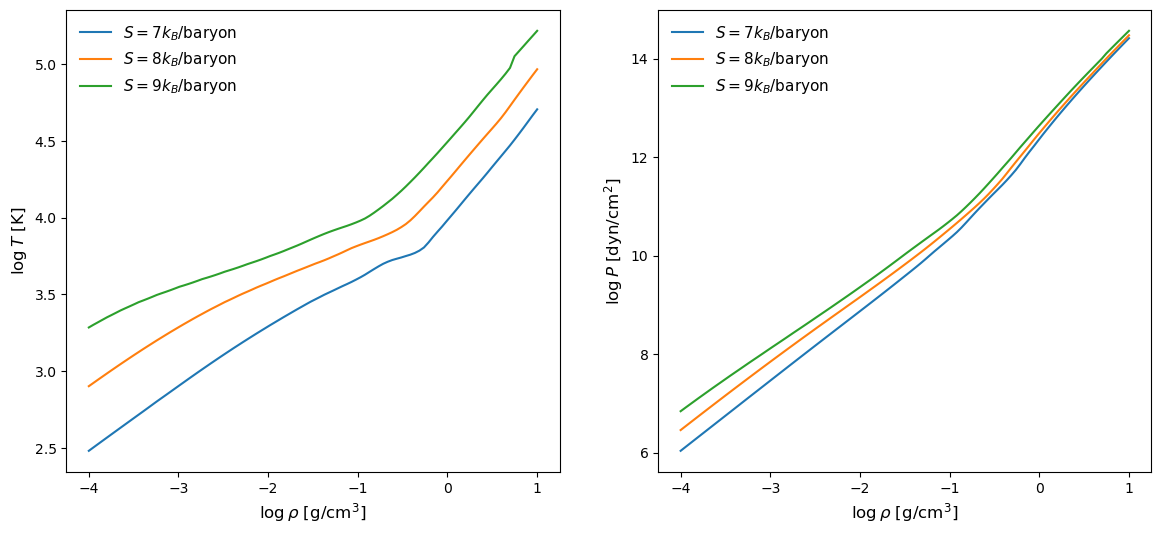

In [5]:
isentropic_s_values = [7, 8, 9] # constant entropy values in kB/baryon
logrho_grid = np.linspace(-4, 1.0, 100)  # log10(rho) in g/cm^3 [10^-4 g/cc to 10 g/cc]
y_value = np.full_like(logrho_grid, 0.25)  # Fixed helium mass fraction (Y)
z_value = np.zeros_like(logrho_grid)  # Zero metallicity for now

cd_eos = eos_class.mixtures(hhe_eos='cd', y_prime=True)

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

for s in isentropic_s_values:
    s_const = np.full_like(logrho_grid, s)  # Constant entropy in kB/baryon
    logp_isentrope, converged = cd_eos.get_logp_srho_inv(s_const, logrho_grid, y_value, z_value)
    logt_isentrope, converged = cd_eos.get_logt_sp_inv(s_const, logp_isentrope, y_value, z_value)

    ax1.plot(logrho_grid, logt_isentrope, label=f'$S = {s} k_B$/baryon')
    ax2.plot(logrho_grid, logp_isentrope, label=f'$S = {s} k_B$/baryon')

ax1.set_xlabel(r'$\log{\rho}$ [g/cm$^3$]', fontsize=12)
ax1.set_ylabel(r'$\log{T}$ [K]', fontsize=12)
ax1.legend(frameon=False, prop={'size': 11})

ax2.set_xlabel(r'$\log{\rho}$ [g/cm$^3$]', fontsize=12)
ax2.set_ylabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax2.legend(frameon=False, prop={'size': 11})

plt.show()

# H-He-Z mixtures

You can initialize the `eos_class.mixtures()` class like before, pass a `z_eos` argument, and make sure that the Z component of the calls to the EOS getters is non-zero.

We'll vary $Z$ here instead of $Y$, like in the H-He EOS mixture example:

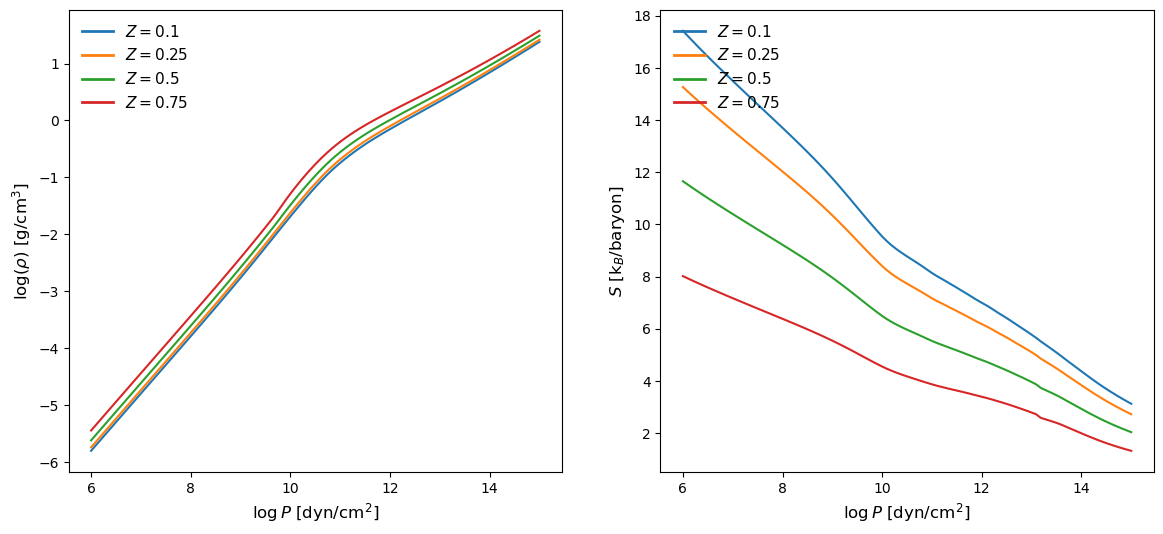

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from eos import eos_class

cd_eos = eos_class.mixtures(hhe_eos='cd', y_prime=True, z_eos='aqua') # CD21 EOS (already incorporates non-ideal corrections via Militzer & Hubbard (2013) and Chabrier et al. (2019))

# Grid from 1 bar to 1000 Mbar in dyn/cm^2
logp_grid = np.linspace(6, 15, 100)  # log10(p) in dyn/cm^2 [1 bar to 1000 Mbar]
logt_const = np.full_like(logp_grid, 4.0)  # log10(T) in K [10,000 K for example here]
y_values = np.full_like(logp_grid, 0.25)  # Mass fractions (Y) of helium
z_values = [0.1, 0.25, 0.5, 0.75]

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

for i, z in enumerate(z_values):
    z_ = np.full_like(logp_grid, z)

    logrho_cd = cd_eos.get_logrho_pt_val(logp_grid, logt_const, y_values, z_)

    ax1.plot(logp_grid, logrho_cd,     color=f'C{i}', ls='-')

    s_cd = cd_eos.get_s_pt_val(logp_grid, logt_const, y_values, z_) * eos_class.erg_to_kbbar  # convert erg/g/K -> k_B/baryon

    ax2.plot(logp_grid, s_cd, color=f'C{i}', ls='-')

# Legend: colors -> Z values (matches the loop above)
color_handles = [
    Line2D([0], [0], color=f'C{i}', ls='-', lw=2, label=rf'$Z = {z}$')
    for i, z in enumerate(z_values)
]

for ax in (ax1, ax2):
    ax.legend(handles=color_handles, frameon=False, loc='upper left', prop={'size': 11})

ax1.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax1.set_ylabel(r'$\log(\rho)$ [g/cm$^3$]', fontsize=12)

ax2.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax2.set_ylabel(r'$S$ [k$_B$/baryon]', fontsize=12)

plt.show()

As you can see, higher metal mass fractions lead to significantly lower entropies at the same $(P, T)$ coordinates. This has consequences for adiabatic temperature inversions: at the same entropy, an H-He-Z mixture will be hotter than a pure H-He mixture. We'll see this directly in the example below.

We'll use the same isentrope example as before, but now instead of varying the entropy, we'll vary the metal mass fraction:

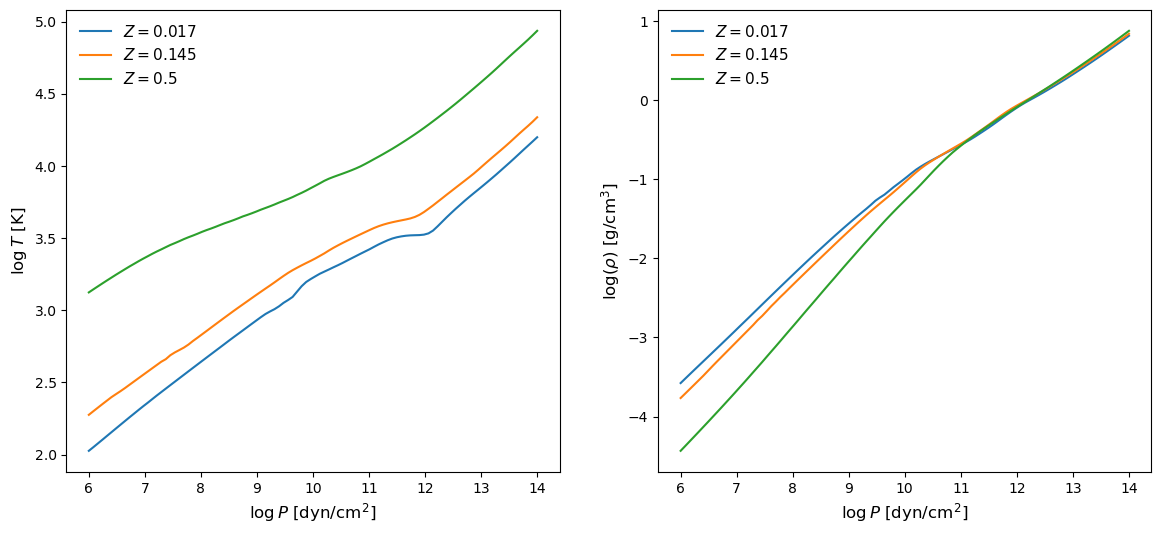

In [7]:

logp_grid = np.linspace(6, 14, 100)  # log10(p) in dyn/cm^2 [1 bar to 100 Mbar]
isentropic_s_value = np.full_like(logp_grid, 5.5) # constant entropy values in kB/baryon (cold adiabat for H-He pure mixture)
y_value = np.full_like(logp_grid, 0.25)  # Fixed helium mass fraction (Y)
z_values = [0.017, 0.145, 0.5] 

cd_eos = eos_class.mixtures(hhe_eos='cd', y_prime=True, z_eos='aqua')

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

for z in z_values:
    z_const = np.full_like(logp_grid, z)  # Constant metallicity
    logt_isentrope, converged = cd_eos.get_logt_sp_inv(isentropic_s_value, logp_grid, y_value, z_const)
    logrho_isentrope = cd_eos.get_logrho_pt_val(logp_grid, logt_isentrope, y_value, z_const)
    ax1.plot(logp_grid, logt_isentrope, label=f'$Z = {z}$')
    ax2.plot(logp_grid, logrho_isentrope, label=f'$Z = {z}$')

ax1.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax1.set_ylabel(r'$\log{T}$ [K]', fontsize=12)
ax1.legend(frameon=False, prop={'size': 11})

ax2.set_xlabel(r'$\log{P}$ [dyn/cm$^2$]', fontsize=12)
ax2.set_ylabel(r'$\log(\rho)$ [g/cm$^3$]', fontsize=12)
ax2.legend(frameon=False, prop={'size': 11})

plt.show()

# Using pure $Z$ EOSes

You can call pure metal EOS functional and table getters. The available python modules are `aqua_eos.py`, `ice_eos.py` for ice mixtures, `ppv2_eos.py` for post-perovskite used in rock mixtures, and others EOSes used in the mantles and cores, such as `mgsio3_comb_eos.py`, `mg2sio4_aneos_eos.py`, and `iron_comb_eos.py`. 

`aqua_eos.py` is, as the name implies, the AQUA water EOS from Haldemann et al. (2020). `ice_eos.py` houses the ammonia and methane EOSes of Bethkenhagen et al. (2017), Setzmann et al. (1991), and Gao et al. (2023), combined with the AQUA EOS for ternary mixtures. 

The MgSiO$_3$ EOS is that published by Luo & Deng (2023), and the Mg$_2$SiO$_4$ EOS is that from Stewart et al. (2020). Iron combined EOS is that of Dorogokupets et al. 2017. 

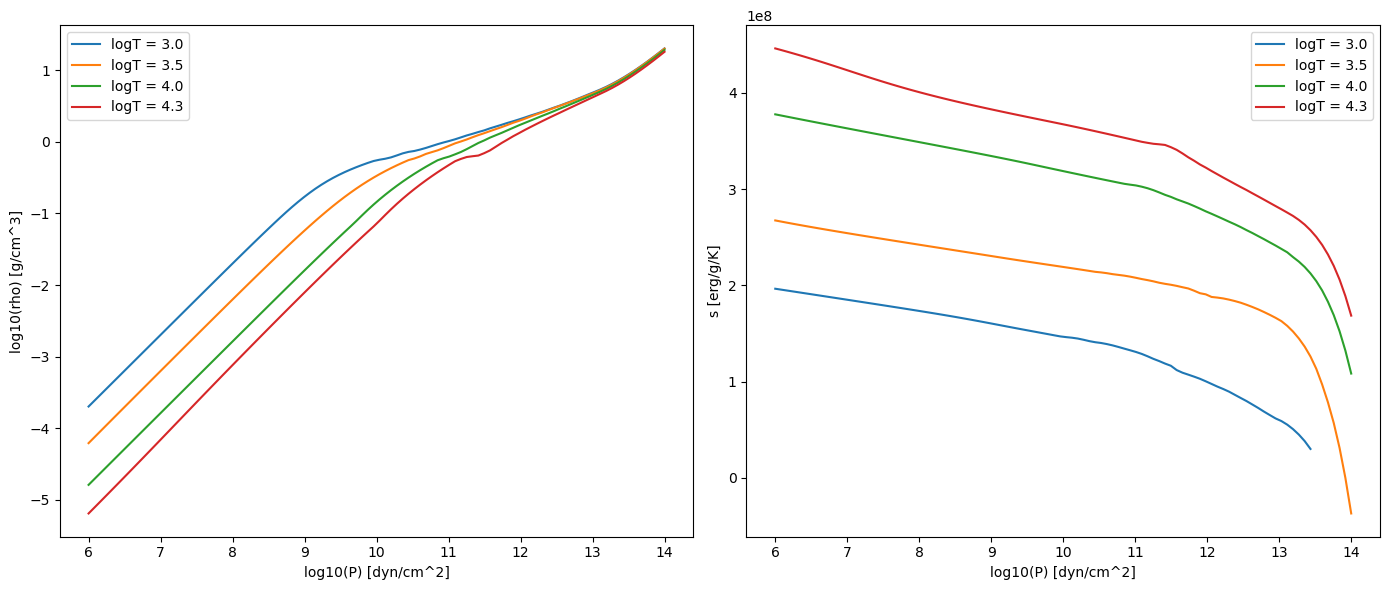

In [8]:
from eos import ice_eos # already includes the water eos
import numpy as np
import matplotlib.pyplot as plt

eos = ice_eos.ice_eos()

zm = 0.75 # 75% methane+ammonia, 25% water by mass
za = 0.5 # 50% of the methane+ammonia mass is methane, 50% is ammonia (so overall 37.5% CH4, 37.5% NH3, 25% H2O by mass)
logpgrid = np.linspace(6, 14, 100)
logt_vals = [3.0, 3.5, 4.0, 4.3]

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
for logt in logt_vals:   
    logrho = eos.get_logrho_pt_val(logpgrid, logt, zm, za)
    s = eos.get_s_pt_val(logpgrid, logt, zm, za)
    ax1.plot(logpgrid, logrho, label=f"logT = {logt}")
    ax2.plot(logpgrid, s, label=f"logT = {logt}")

ax1.legend()
ax2.legend()
ax1.set_xlabel("log10(P) [dyn/cm^2]")
ax1.set_ylabel("log10(rho) [g/cm^3]")
ax2.set_xlabel("log10(P) [dyn/cm^2]")
ax2.set_ylabel("s [erg/g/K]")
plt.tight_layout()
plt.show()

## Varying the amount of methane/ammonia in water mixtures

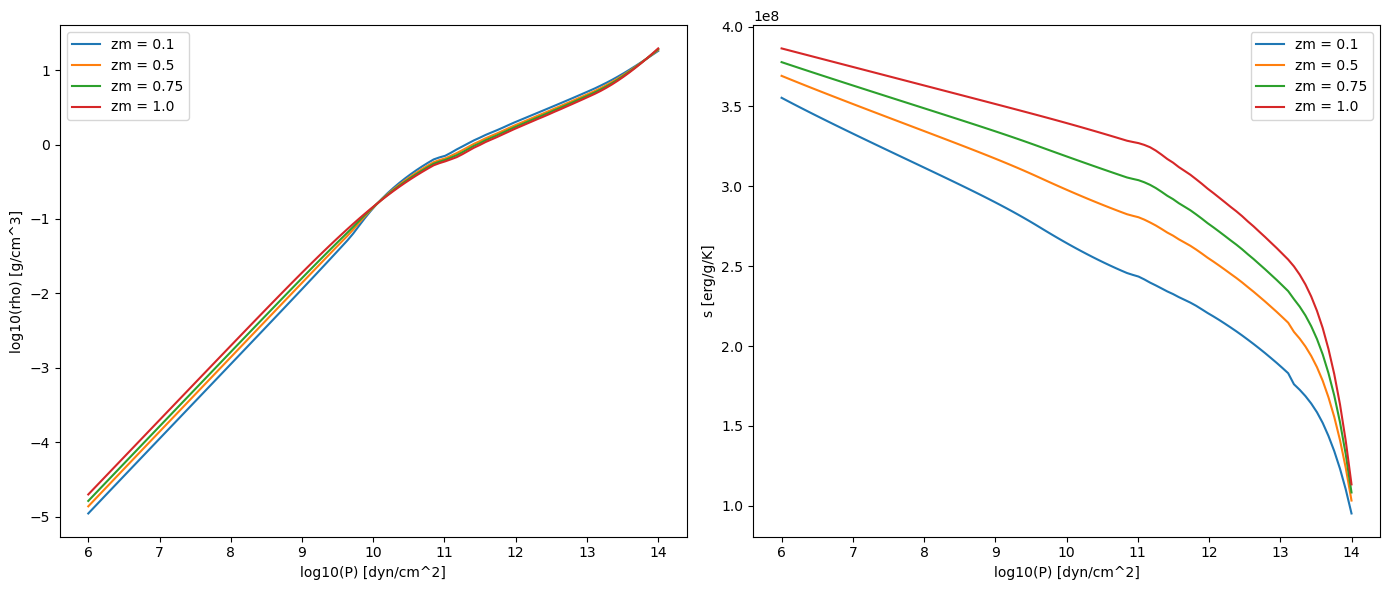

In [9]:
from eos import ice_eos
import numpy as np
import matplotlib.pyplot as plt

eos = ice_eos.ice_eos()

zm = [0.1, 0.5, 0.75, 1.0]
za = 0.5
logpgrid = np.linspace(6, 14, 100)
logt_vals = 4.0

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
for _zm in zm:   
    logrho = eos.get_logrho_pt_val(logpgrid, logt_vals, _zm, za)
    s = eos.get_s_pt_val(logpgrid, logt_vals, _zm, za)
    ax1.plot(logpgrid, logrho, label=f"zm = {_zm}")
    ax2.plot(logpgrid, s, label=f"zm = {_zm}")

ax1.legend()
ax2.legend()
ax1.set_xlabel("log10(P) [dyn/cm^2]")
ax1.set_ylabel("log10(rho) [g/cm^3]")
ax2.set_xlabel("log10(P) [dyn/cm^2]")
ax2.set_ylabel("s [erg/g/K]")
plt.tight_layout()
plt.show()

## Varying the amount of Ammonia within the methane/ammonia ratio

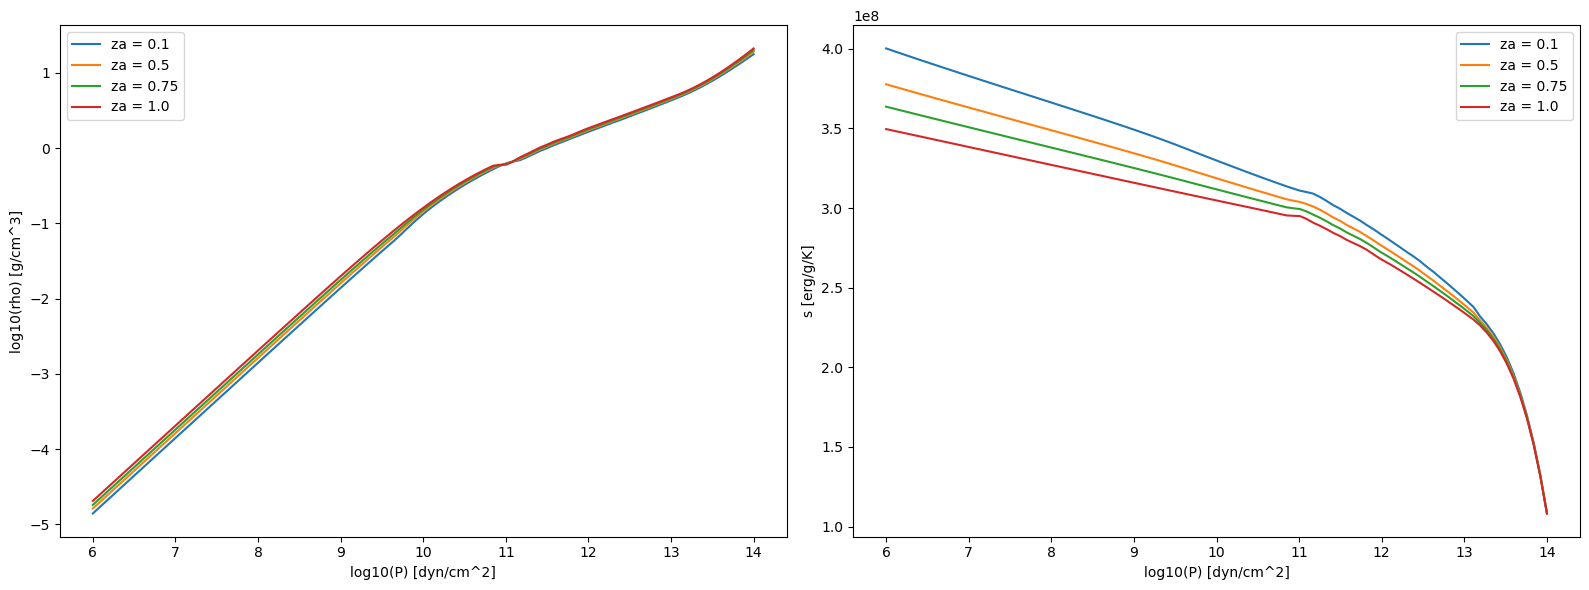

In [10]:
from eos import ice_eos
import numpy as np
import matplotlib.pyplot as plt
eos = ice_eos.ice_eos()

zm = 0.75
za = [0.1, 0.5, 0.75, 1.0]
logpgrid = np.linspace(6, 14, 100)
logt_vals = 4.0

plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
for _za in za:   
    logrho = eos.get_logrho_pt_val(logpgrid, logt_vals, zm, _za)
    s = eos.get_s_pt_val(logpgrid, logt_vals, zm, _za)
    ax1.plot(logpgrid, logrho, label=f"za = {_za}")
    ax2.plot(logpgrid, s, label=f"za = {_za}")

ax1.legend()
ax2.legend()
ax1.set_xlabel("log10(P) [dyn/cm^2]")
ax1.set_ylabel("log10(rho) [g/cm^3]")
ax2.set_xlabel("log10(P) [dyn/cm^2]")
ax2.set_ylabel("s [erg/g/K]")
plt.tight_layout()
plt.show()

# EOSes for the cores in ORCHARD

The following are examples on how to call AQUA, Mg2SiO4, and the iron EOSes used the core of sub-Neptunes, and gas giants. These are the same EOSes that can be used for the mantles and cores of super-Earth models (see `tutorial_subneptunes_superearths.ipynb`).

This section will only show the isentropes of each EOS at a given pressure range.

## AQUA EOS

This core version of AQUA is found in `aqua_core_eos.py`.

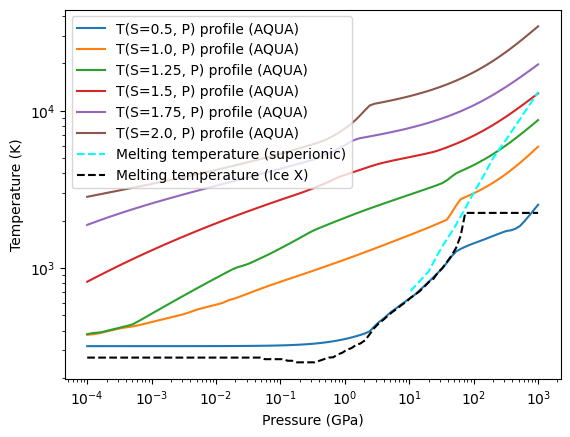

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from eos import aqua_core_eos as aqua

aqua_eos = aqua.AQUA_CORE_EOS()

P_grid = np.logspace(-4, 3, 100)  # GPa units here [IMPORTANT: the eos expects pressure in GPa for this model] in linear space (not log10)
s_const = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0]  # constant entropy in kB/baryon

for s in s_const:
    T_res_AQUA = aqua_eos.get_t_sp(s, P_grid, tab=True)
    plt.loglog(P_grid, T_res_AQUA, label=f'T(S={s}, P) profile (AQUA)')
T_melt_superionic = aqua_eos.get_T_melt(P_grid, phase='superionic')
plt.loglog(P_grid, T_melt_superionic, label='Melting temperature (superionic)', linestyle='--', color='cyan')
T_melt_ice_x = aqua_eos.get_T_melt(P_grid, phase='ice_x')
plt.loglog(P_grid, T_melt_ice_x, label='Melting temperature (Ice X)', linestyle='--', color='black')
plt.xlabel('Pressure (GPa)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()


### AQUA v1.0 vs. the revised AQUA (EOS v2.0)

The AQUA tables we just used are the original Haldemann et al. (2020) release, which ships as `z_eos = aqua` and which we'll call v1.0. The v2.0 EOS release adds the revised AQUA of Cano Amoros et al., with entropies re-derived from Mazevet et al. (2021) and superionic data from French et al. (2016). Just as importantly, the revised release ships the analytic thermodynamic derivatives ($\partial \ln S/\partial \ln T|_P$, $\partial \ln S/\partial \ln P|_T$, and the adiabatic gradient) alongside the table instead of leaving them to be finite-differenced from it. In `ORCHARD` configs the revised water enters through the v2.0 metal options (`z_eos = aqua_revised` for pure water, `aquarock` for a water+rock mixture; see `[equation_of_state]` in `parameters_default.ini`), while v1.0 `aqua` remains the default for continuity with published results.

Both versions are exposed through wrapper classes sharing the same units convention ($P$ in GPa, $T$ in K, $\rho$ in g/cm$^3$, $S$ in erg/g/K), so we can diff them directly. First, a fact worth establishing rather than asserting. The density surface is untouched by the revision:

max |rho_v2/rho_v1 - 1| over the sampled isotherms: 0.00e+00


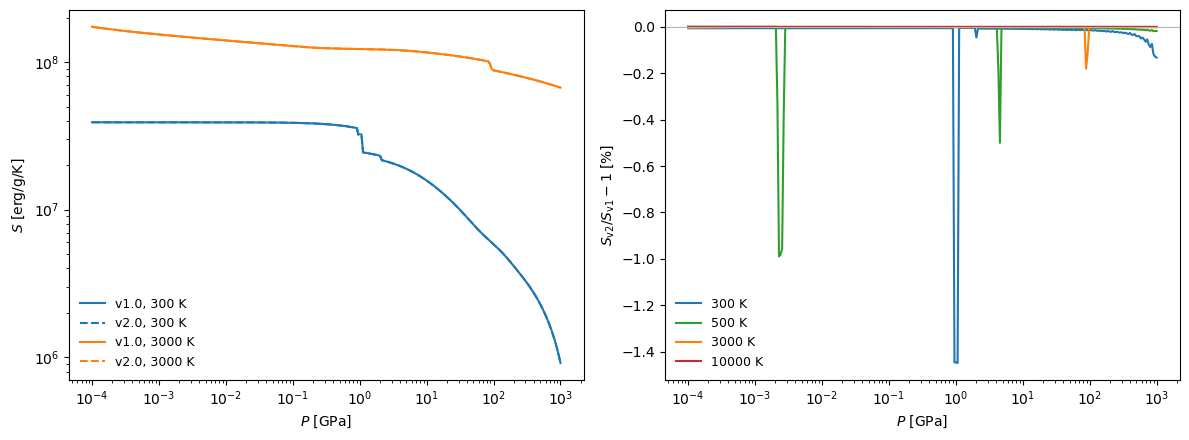

In [12]:
from eos.aqua_core_eos import AQUA_CORE_EOS
from eos.aqua_revised_core_eos import AQUA_REVISED_CORE_EOS

aqua_v1 = AQUA_CORE_EOS()
aqua_v2 = AQUA_REVISED_CORE_EOS()

P_grid = np.logspace(-4, 3, 300)   # 0.1 kPa to 1000 GPa

# Density: identical by construction
drho_max = 0.0
for T in (300.0, 1000.0, 3000.0, 10000.0):
    T_arr = np.full_like(P_grid, T)
    r1 = aqua_v1.get_rho_pt(P_grid, T_arr, tab=True)
    r2 = aqua_v2.get_rho_pt_tab(P_grid, T_arr)
    drho_max = max(drho_max, np.nanmax(np.abs(r2 / r1 - 1)))
print(f'max |rho_v2/rho_v1 - 1| over the sampled isotherms: {drho_max:.2e}')

# Entropy: this is where the revision lives
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for T, colr in [(300.0, 'C0'), (3000.0, 'C1')]:
    T_arr = np.full_like(P_grid, T)
    s1 = aqua_v1.get_s_pt(P_grid, T_arr, tab=True)
    s2 = aqua_v2.get_s_pt_tab(P_grid, T_arr)
    ax1.loglog(P_grid, s1, color=colr, label=f'v1.0, {T:.0f} K')
    ax1.loglog(P_grid, s2, color=colr, ls='--', label=f'v2.0, {T:.0f} K')
for T, colr in [(300.0, 'C0'), (500.0, 'C2'), (3000.0, 'C1'), (10000.0, 'C3')]:
    T_arr = np.full_like(P_grid, T)
    s1 = aqua_v1.get_s_pt(P_grid, T_arr, tab=True)
    s2 = aqua_v2.get_s_pt_tab(P_grid, T_arr)
    ax2.semilogx(P_grid, 100 * (s2 / s1 - 1), color=colr, label=f'{T:.0f} K')

ax1.set_xlabel(r'$P$ [GPa]'); ax1.set_ylabel(r'$S$ [erg/g/K]')
ax1.legend(frameon=False, fontsize=9)
ax2.set_xlabel(r'$P$ [GPa]'); ax2.set_ylabel(r'$S_{\rm v2}/S_{\rm v1} - 1$ [%]')
ax2.axhline(0, color='0.7', lw=0.8)
ax2.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

So the densities are identical and the entropies are revised, and the entropy differences are not uniform. They concentrate exactly where water thermodynamics is hardest: up to $\sim 1.5\%$ in the cold ice regime (300 K near 1 GPa), $\sim 1\%$ at low pressures for warm water, and $\sim 0.15\%$ around the superionic transition at 3000 K, while staying at the $10^{-6}$ level across the benign parts of the plane.

Small numbers? Not for evolution. Entropy is the quantity an evolution code integrates, so a percent-level entropy offset at a phase boundary shifts where the adiabat crosses it, and for a water-rich sub-Neptune that moves the superionic boundary and the inferred thermal state of the deep interior. The analytic derivatives matter for the same reason. `ORCHARD`'s transport solve consumes $\partial S$ derivatives, and finite-differencing a table near a phase boundary is exactly where numerical derivatives misbehave. A model evolved with `z_eos = aqua` and one with `aqua_revised` are therefore not interchangeable mid-run. Pick one per project and note it in your methods section.

**NOTE**: The melting and superionic phase boundaries (`get_T_melt`, `get_T_melt_superionic`) are shared between the two classes, since they describe the same substance and the same phase diagram. Feel free to redo the phase-boundary plot above with `aqua_v2`; you should get an identical figure. What changes is the thermodynamics you integrate through those boundaries.

## Rock EOS

The following EOS combines the liquid Mg2SiO4 EOS Stewart et al. (2020) from ANEOS (Thompson et al. 1990). We can call and plot a few isentropes here. Note that the pressure here is now in GPa instead of log 10 dyn/cm^2

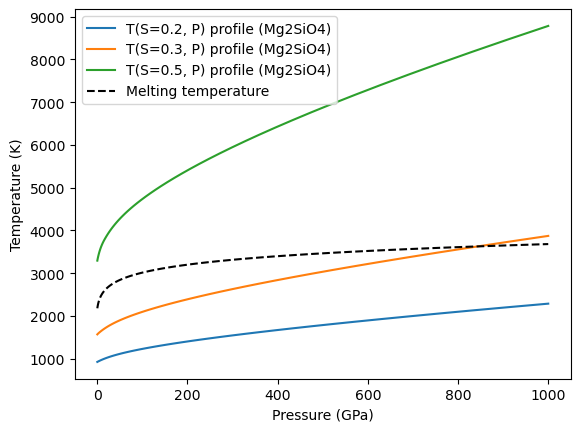

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from eos import mg2sio4_aneos_eos as mg2sio4

mg2sio4_eos = mg2sio4.MG2SIO4_ANEOS_EOS()

P_grid = np.logspace(-1, 3, 100)  # GPa units here [IMPORTANT: the eos expects pressure in GPa for this model] in linear space (not log10)
s_const = [0.2, 0.3, 0.5]  # constant entropy in kB/baryon

for s in s_const:
    T_res_mg2sio4 = mg2sio4_eos.get_t_sp_inv(s, P_grid)
    plt.plot(P_grid, T_res_mg2sio4, label=f'T(S={s}, P) profile (Mg2SiO4)')
T_melt = mg2sio4_eos.get_T_melt(P_grid)

plt.plot(P_grid, T_melt, label='Melting temperature', linestyle='--', color='black')
plt.xlabel('Pressure (GPa)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()


Derivative, analytic ($\rho, T$) basis, and $P, T$ basis are available for the rock, iron, and iron alloy EOSes. These are used for the mantles and cores of sub-Neptune models and super-Earth models in `ORCHARD`. 

# Making your own mixture EOSes

You may want to use another EOS to combine the H-He EOS with, or you may want a different H-He-ice mixture other than the 4:1:7 C:N:O ratio that I've provided here. 

One challenge here is that `ORCHARD` relies on pre-computed tables because real-time inversions are expensive to compute (e.g., $T(S, P)$ and all the inversions necessary to get the derivatives).

The way that we've done it for a simple H-He-$Z$ EOS is to pre-calculate all of the $P, T$, $\rho, T$, $S,P$, and $S, \rho$ components in the relevant thermodynamic space for regularly spaced $Y$ and $Z$ fractions, from 0.0 ($Z$) or 0.05 ($Y'$) to 1.0. We do this in $Y'$ space where $Y' = Y/(1 - Z)$ so that the grids are regularly spaced in $Y$ across all mixtures.

To start, you can use the provided `eos_pt_calc.py` module. Let's say you want to calculate a different C:N:O ratio of 1:1:1. You can run:

`python eos_pt_calc.py --hhe_eos cd --z_eos ice_mixture -cno_ratio 111`

The default H-He EOS used here is the CD21 EOS. You can change this by passing, say, `--hhe_eos cms` or `--hhe_eos scvh`. 

By default, `eos_pt_calc.py` will calculate the table values between 1 and 100 Mbar in log10 cgs units. The default table arrays are:

```
logpvals = np.arange(6, 14.05, 0.05) # between 1 bar and 100 Mbar in steps of 0.05 cgs dex
if args.z_eos == 'ice_mixture' or args.z_eos == 'ice_rock':
    logtvals = np.arange(2.1, 4.35, 0.05) # between 125 K and 22,400 K in steps of 0.05 dex
else:
    logtvals = np.arange(2.1, 5.0, 0.05) # between 125 K and 100,000 K in steps of 0.05 dex
yvals = np.arange(0.05, 1.0, 0.05) # between 0.05 and 0.95 in steps of 0.05 (Y' = He mass fraction in H-He sub-mixture)
zvals = np.arange(0, 1.01, 0.01) # between 0 and 1 in steps of 0.01 (Z = total metal mass fraction)
```

The methane and ammonia EOSes have an upper limit of around 22,400 K, so I limit the ice mixtures to this upper limit. If doing only water or rock mixtures, this can go higher to 100,000 K.

If you'd rather do your own range, you can change this to 
```
# Terminal with prompts:
python eos_pt_calc.py --z_eos ice_mixture --cno_ratio 111 --custom_range True

# Example prompt interaction:
#   log10(P) [dyn/cm2]  [default: 6.0, 14.0, 0.05]
#     min, max, step (or press Enter for defaults): 10, 12, 0.5
```


## Example: CNO 1:1:1

After you run `python eos_pt_calc.py --z_eos ice_mixture --cno_ratio 111`, once the progress bar finishes, you should see a new saved file called `eos/cd/cd_ice_mixture_cno111_aqua_pt.npz.`. 

Let's say you decided to do your own table range instead, and did the following:

```
(orchard_env) user@computer orchard % python eos_pt_calc.py --z_eos ice_mixture --cno_ratio 111 --custom_range True
Calculating PT table for: hhe=cd, z_eos=ice_mixture, z_eos1 = aqua, f_ppv = 0.0

### terminal output:
--- Custom grid range setup ---
For each axis, enter: min, max, step
(The endpoint is always included.)

Reference points for log10(P / dyn cm-2):
    6  = 1 bar,  10 = 10 kbar,  12 = 1 Mbar,  14 = 100 Mbar
Reference points for log10(T / K):
    2  = 100 K,  3 = 1000 K,  4 = 10,000 K

  log10(P) (log10 dyn/cm2; 6=1bar, 12=1Mbar)  [default: 6.0, 14.0, 0.05]
    min, max, step (or press Enter for defaults): 5.0, 15.0, 0.05 
    -> log10(P): 5 to 15, 201 points, step 0.05
  log10(T) (log10 K; 3=1000K, 4=10000K)  [default: 2.1, 4.3, 0.05]
    min, max, step (or press Enter for defaults): 2.1, 4.3, 0.05
    -> log10(T): 2.1 to 4.3, 45 points, step 0.05
  Y' (He mass fraction in H-He, 0 to 1)  [default: 0.05, 0.95, 0.05]
    min, max, step (or press Enter for defaults): 0.05, 0.95, 0.05
    -> Y': 0.05 to 0.95, 19 points, step 0.05
  Z (total metal mass fraction, 0 to 1)  [default: 0.0, 1.0, 0.01]
    min, max, step (or press Enter for defaults): 0.0, 1.0, 0.01
    -> Z: 0 to 1, 101 points, step 0.01

Total grid points: 17,357,355

Ice mixture CNO ratio: 1:1:1?"
  ice_eos params -> zm: 0.4710, za: 0.3334
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [01:45<00:00,  1.91it/s]
FINISHED FROCK=0.0
Data saved successfully to eos/cd/cd_ice_mixture_cno111_aqua_custom_pt.npz.
```

Then, you can inspect the raw table before saving any inversions, like so:

```python
import numpy as np

data = np.load('eos/cd/cd_ice_mixture_cno111_aqua_custom_pt.npz')
print(data.files)
# ['logpvals', 'logtvals', 'yvals', 'zvals', 's_pt', 'logrho_pt', 'logu_pt']
print(data['s_pt'].shape)   # (P, T, Y', Z) grid
```

`ORCHARD ` takes a full data table set in $S,P$, $\rho,T$, and $S, \rho$ space to calculate derivatives, such as $\partial S/\partial Y|_{\rho, P}$ for the Ledoux criterion for convection (see Tejada Arevalo et al. 2024 for a discussion). So to make your C:N:O 111 table work in `ORCHARD`, you'll need to spend some time inverting to S,P space using the inversion functions. These functions are in `eos_class.py`, identified by `_inv` suffixes (`get_logt_sp_inv()` for example). 

# Comparing H-He EOSes: CD21 vs. CMS19

`ORCHARD`'s recommended H-He EOS is Chabrier & Debras (2021) (`hhe_eos = cd`), with Chabrier et al. (2019) (`cms`) available for comparison and for reproducing older work. The two share a lineage but differ in how the hydrogen table handles the pressure-dissociation and metallization region, and those differences propagate directly into predicted radii and cooling times, so it's worth seeing where they live. Let's load the CD21 tables alongside the CMS19 object from earlier and compare pure-hydrogen densities and entropies along an isotherm:

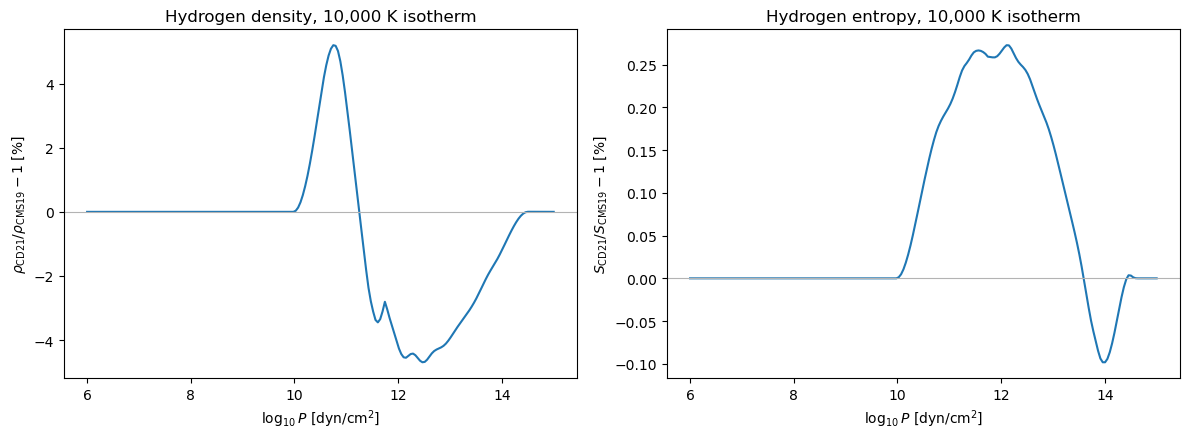

In [14]:
cd_eos = eos_class.hhe_eos(hhe_eos='cd')  # Chabrier & Debras (2021)

logp_grid = np.linspace(6, 15, 200)          # 1 bar to 1000 Mbar
logt_const = np.full_like(logp_grid, 4.0)    # 10,000 K isotherm

logrho_H_cms = cms_eos.get_logrho_h(logp_grid, logt_const)
logrho_H_cd  = cd_eos.get_logrho_h(logp_grid, logt_const)
s_H_cms = cms_eos.get_s_h(logp_grid, logt_const)
s_H_cd  = cd_eos.get_s_h(logp_grid, logt_const)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(logp_grid, 100 * (10**logrho_H_cd / 10**logrho_H_cms - 1))
ax1.axhline(0, color='0.7', lw=0.8)
ax1.set_xlabel(r'$\log_{10} P$ [dyn/cm$^2$]')
ax1.set_ylabel(r'$\rho_{\rm CD21}/\rho_{\rm CMS19} - 1$ [%]')
ax1.set_title('Hydrogen density, 10,000 K isotherm')

ax2.plot(logp_grid, 100 * (s_H_cd / s_H_cms - 1))
ax2.axhline(0, color='0.7', lw=0.8)
ax2.set_xlabel(r'$\log_{10} P$ [dyn/cm$^2$]')
ax2.set_ylabel(r'$S_{\rm CD21}/S_{\rm CMS19} - 1$ [%]')
ax2.set_title('Hydrogen entropy, 10,000 K isotherm')

plt.tight_layout()
plt.show()

The differences concentrate around $\log_{10} P \sim 11$ to $13$ (roughly 0.1 to 10 Mbar), the molecular-to-metallic hydrogen transition, which is exactly the region that sets the deep interior structure of Jupiter- and Saturn-mass planets. Percent-level density differences here translate into distinguishable radii at fixed age. This is why swapping `hhe_eos` between `cd` and `cms` (and toggling the Howard & Guillot 2023 corrections via `hg` on `cms`) is one of the cheapest and most instructive sensitivity tests you can run on any gas giant model.

# Exercises

A few things to try that will make the EOS layer feel much less like a black box. None of them require running an evolution model.

1. **Isotherm sweep.** Redo the CD21 vs. CMS19 comparison above at $\log_{10} T = 3.0$ and $4.3$. Does the disagreement region move with temperature? At which conditions do the two EOSes essentially agree?

2. **The metallicity lever.** Using the `mixtures` class from earlier, compute $\rho(P)$ along a $\log_{10} T = 4$ isotherm for $Z = 0$, $0.02$, $0.10$, and $0.30$ (fixed $Y' = 0.245$). How much denser is a $Z = 0.10$ mixture than a $Z = 0$ mixture at 1 Mbar? Now you know why metal-rich planets are smaller at fixed mass.

3. **Adiabat shifts.** Use `get_logt_sp` to compute the $T(P)$ adiabat at $S = 6$ k$_B$/baryon for the same set of $Z$ values. How much hotter is the $Z = 0.30$ adiabat at 10 Mbar? Connect this to the discussion in the H-He-Z mixtures section above.

4. **Water in three phases.** With the AQUA EOS, evaluate the density at $P = 1$ GPa for $T = 300$, $1000$, and $3000$ K, and locate each point against the melting and superionic curves you plotted earlier. Which phase is each point in?

5. **Roll your own table.** Use `eos_pt_calc.py` to build a small custom mixture table (the custom-range flags keep it quick), load the resulting `.npz` as shown above, and spot-check three $(P, T, Y', Z)$ points against the on-the-fly `_val` getters. Tabulated and direct evaluations should agree to interpolation accuracy. If they don't, you've found either a bug or an extrapolation region, and I'd like to hear about both.

6. **EOS choice as an error bar.** For a homogeneous Jupiter (see `tutorial_solarsystem_planets.ipynb`), run the same model once with `hhe_eos = cd` and once with `hhe_eos = cms`, and overplot the radius evolution. The spread between those two curves is an honest lower bound on the systematic uncertainty every gas giant evolution calculation carries. This one does require evolution runs, so consider it the capstone.

# Conclusion

That's the EOS submodule in a nutshell: the H-He EOSes, the `mixtures()` class that `ORCHARD` actually evolves with, the pure-$Z$ and core EOSes, and the machinery to roll your own tables. Making a full custom table set is a time investment, but if you do make one (a different C:N:O ratio, a new rock mixture), I'd be happy to hear about it. Feel free to open an issue or pull request.